# Кластеризация клиентов (Customer Personality Analysis)

**Задача:** выделить сегменты клиентов по доходу, тратам и активности покупок.

Алгоритмы: **KMeans**, **DBSCAN**, **иерархическая кластеризация**.  

In [146]:
# Импорты
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (8, 4.5)
sns.set_style("whitegrid")


## 1. Загрузка и первичный анализ

Кластеризация ищет группы похожих клиентов **без готовых меток**.  
Сначала выбираем числовые признаки поведения (доход, траты `Mnt*`, покупки `Num*`, `Recency`) и проверяем пропуски, выбросы и распределения.


In [147]:
# Файл разделён табуляцией, не запятыми
df = pd.read_csv("Customer Segmentation_Based_on_Spending_Behavior.csv", sep="\t")

print("Размер:", df.shape)
print("Колонки:", list(df.columns))
df.head()


Размер: (2240, 29)
Колонки: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# Числовые признаки для кластеризации
feature_cols = [
    "Income",
    "Recency",
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
    "NumStorePurchases", "NumWebVisitsMonth",
]

# Берём копию нужных столбцов
data = df[feature_cols].copy()

print("Пропуски:")
print(data.isna().sum())
print("\nОписательная статистика:")
display(data.describe().T)


Пропуски:
Income                 24
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
dtype: int64

Описательная статистика:


,count,mean,std,min,25%,50%,75%,max
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.062946,41.280498,0.0,1.00,8.0,33.00,263.0
MntGoldProds,2240.0,44.021875,52.167439,0.0,9.00,24.0,56.00,362.0
NumDealsPurchases,2240.0,2.325000,1.932238,0.0,1.00,2.0,3.00,15.0
NumWebPurchases,2240.0,4.084821,2.778714,0.0,2.00,4.0,6.00,27.0


In [149]:
# Заполняем пропуски Income медианой (устойчивее среднего к выбросам)
income_median = data["Income"].median()
data["Income"] = data["Income"].fillna(income_median)

# Убираем явный выброс дохода (в данных встречается 666666)
n_before = len(data)
data = data[data["Income"] < 200000].copy()
print("Удалено строк с экстремальным Income:", n_before - len(data))
print("Пропусков после обработки:", int(data.isna().sum().sum()))


Удалено строк с экстремальным Income: 1
Пропусков после обработки: 0


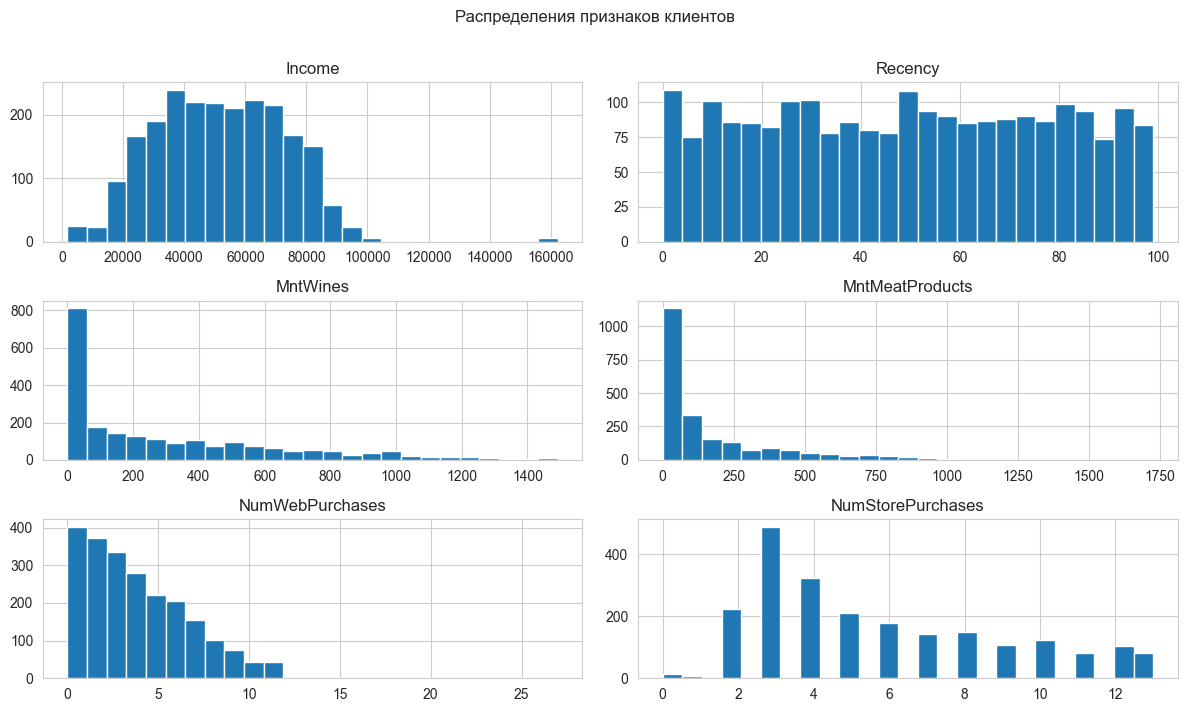

In [150]:
# Распределения ключевых признаков
plot_cols = ["Income", "Recency", "MntWines", "MntMeatProducts", "NumWebPurchases", "NumStorePurchases"]
data[plot_cols].hist(bins=25, figsize=(12, 7), edgecolor="white")
plt.suptitle("Распределения признаков клиентов", y=1.01)
plt.tight_layout()
plt.show()


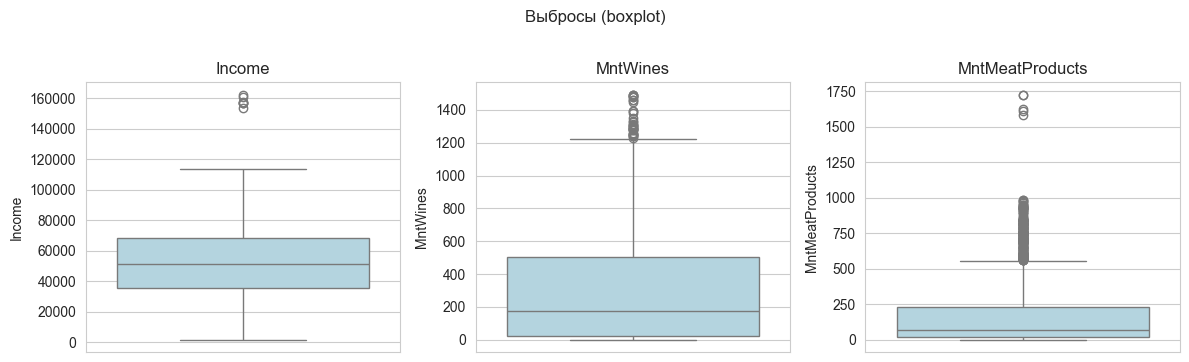

In [151]:
# Boxplot для поиска выбросов по тратам и доходу
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, ["Income", "MntWines", "MntMeatProducts"]):
    sns.boxplot(y=data[col], ax=ax, color="lightblue")
    ax.set_title(col)
plt.suptitle("Выбросы (boxplot)", y=1.02)
plt.tight_layout()
plt.show()


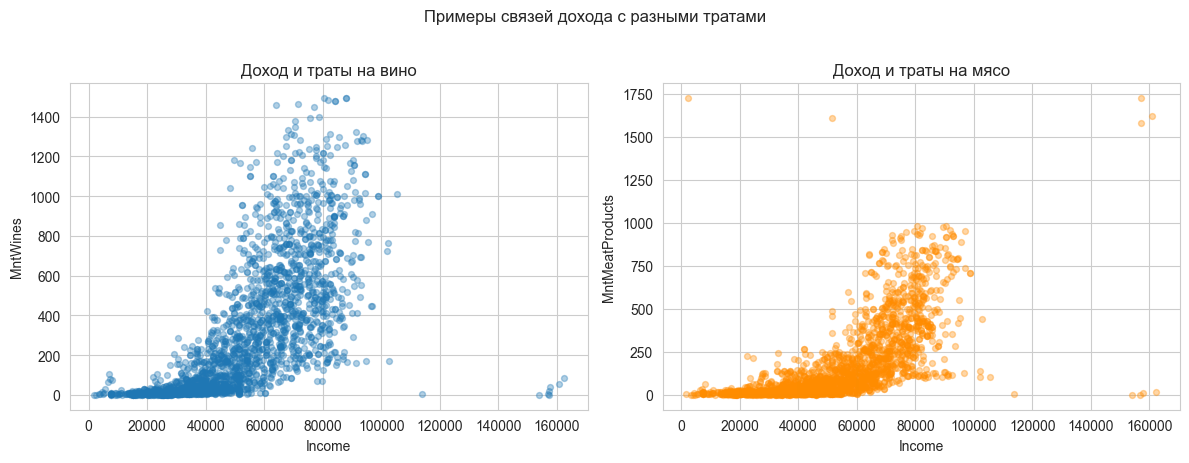

In [152]:
# Строим точечную диаграмму для дохода и трат на вино и мясо, чтобы визуально оценить их связь
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Пример 1: доход и траты на вино
axes[0].scatter(data["Income"], data["MntWines"], alpha=0.35, s=18)
axes[0].set_xlabel("Income")
axes[0].set_ylabel("MntWines")
axes[0].set_title("Доход и траты на вино")

# Пример 2: доход и траты на мясо
axes[1].scatter(data["Income"], data["MntMeatProducts"], alpha=0.35, s=18, color="darkorange")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("MntMeatProducts")
axes[1].set_title("Доход и траты на мясо")

plt.suptitle("Примеры связей дохода с разными тратами", y=1.02)
plt.tight_layout()
plt.show()


### Вывод по пункту 1

1. В данных были пропуски в `Income` (заполнили медианой) и экстремальный выброс дохода.  
2. Траты и доход скошены вправо: много «средних» клиентов и хвост более состоятельных.  
3. На scatter по **вину** и по **мясу** видно одно и то же: при росте дохода траты обычно выше, но клиенты неоднородны — кластеризация имеет смысл.


## 2. Масштабирование данных

KMeans, DBSCAN и иерархия считают **расстояния**.  
`Income` ~ десятки тысяч, а `NumWebPurchases` ~ единицы. Без масштабирования доход «перетянет» всё расстояние на себя.


In [153]:
# StandardScaler: среднее 0, дисперсия 1 для каждого признака
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[feature_cols])  # учим и преобразуем
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=data.index)

print("После масштабирования:")
print("mean ≈ 0:", np.round(X_scaled.mean().mean(), 5))
print("std  ≈ 1:", np.round(X_scaled.std(ddof=0).mean(), 5))


После масштабирования:
mean ≈ 0: 0.0
std  ≈ 1: 1.0


### Почему масштабируем эти признаки

Масштабируем **все** выбранные числовые признаки (`Income`, `Recency`, `Mnt*`, `Num*`), потому что:
1. у них разные единицы и диапазоны;
2. алгоритмы кластеризации опираются на евклидово расстояние (насколько два клиента далеки друг от друга по их числам);
3. без `StandardScaler` кластеры почти наверняка строились бы в основном по доходу, а не по поведению в целом.


## 3. KMeans-кластеризация

**Теория на нашей задаче.**  
KMeans делит клиентов на `k` групп: ищет центры и относит каждого клиента к ближайшему центру.  
Ниже перебираем `k = 1…10` и рисуем кластеры на 2D (PCA), чтобы глазами увидеть разделение.


In [154]:
# Для картинки сжимаем 13 признаков в 2 главные компоненты
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)

print("Доля объяснённой дисперсии PCA:", np.round(pca.explained_variance_ratio_.sum(), 3))


Доля объяснённой дисперсии PCA: 0.566


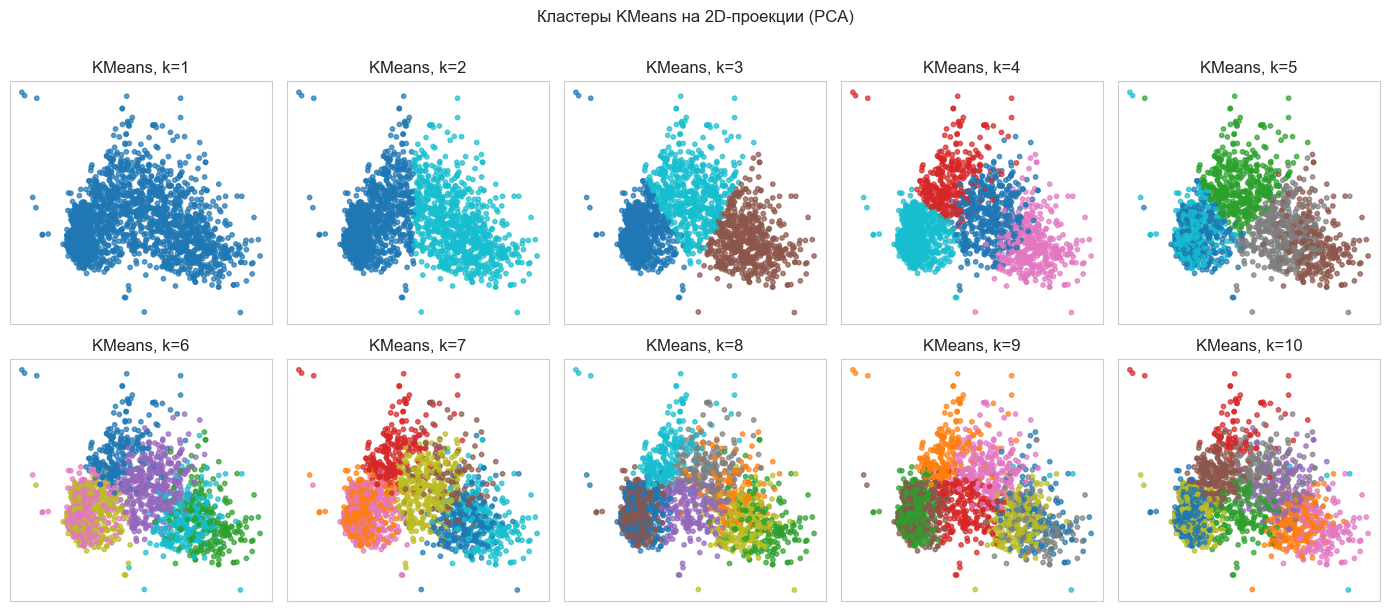

In [155]:
# KMeans для k от 1 до 10 + визуализация на плоскости PCA
# Важно: длина ks и число subplot должны совпадать
ks = range(1, 11)  # 1,2,...,10 → всего 10 значений
kmeans_models = {}
labels_by_k = {}

fig, axes = plt.subplots(2, 5, figsize=(14, 6))  # 10 окон под 10 значений k
axes = axes.ravel()

for ax, k in zip(axes, ks):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)  # метки кластеров
    kmeans_models[k] = km
    labels_by_k[k] = labels

    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", s=10, alpha=0.7)
    ax.set_title(f"KMeans, k={k}")
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Кластеры KMeans на 2D-проекции (PCA)", y=1.01)
plt.tight_layout()
plt.show()


### Вывод по пункту 3

При малом `k` группы крупные и грубые; при большом `k` дробление сильнее.  

Визуально оптимальными вариантами выглядят 3 или 4.

Оптимальное `k` выберем по локтю, silhouette и другим метрикам ниже.



## 4. Метод локтя (Elbow Method)

`inertia` — сумма квадратов расстояний клиентов до центра своего кластера.  
Чем больше `k`, тем меньше inertia. «Локоть» — место, где спад замедляется: дальше дробить уже мало пользы.


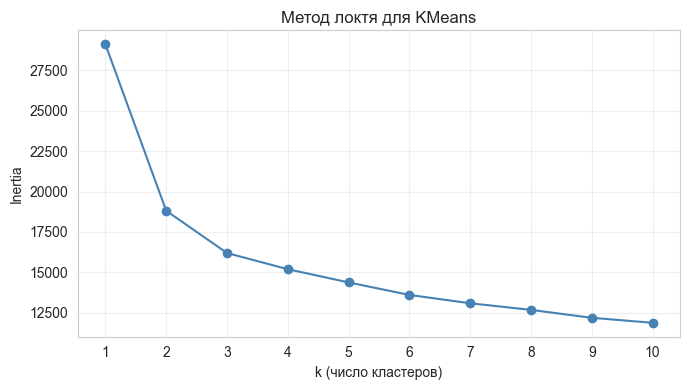

Эвристика локтя (по вторым разностям): k ≈ 2


In [156]:
# Считаем inertia для каждого k
inertias = [kmeans_models[k].inertia_ for k in ks]

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, "o-", color="steelblue")
plt.xticks(list(ks))
plt.xlabel("k (число кластеров)")
plt.ylabel("Inertia")
plt.title("Метод локтя для KMeans")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Простая эвристика: максимальный «излом» по вторым разностям
deltas = np.diff(inertias)
second = np.diff(deltas)
elbow_k = list(ks)[np.argmax(second) + 1]  # +1 из-за двойного diff
print("Эвристика локтя (по вторым разностям): k ≈", elbow_k)


### Вывод по пункту 4

По локтю inertia заметный излом около **k ≈ 2**.  
Это кандидат, но окончательно выберем `k` вместе с silhouette и другими метриками.


## 5. Silhouette Score

Silhouette (силуэт) показывает: клиент ближе к **своему** кластеру, чем к чужим?  
Диапазон примерно от -1 до 1: чем ближе к 1, тем лучше разделение.


In [157]:
# Silhouette считаем только для k >= 2 (при k=1 одного кластера недостаточно)
silhouette_scores = {}
for k in ks:
    if k < 2:
        continue
    silhouette_scores[k] = silhouette_score(X_scaled, labels_by_k[k])

sil_df = pd.DataFrame({
    "k": list(silhouette_scores.keys()),
    "silhouette": list(silhouette_scores.values()),
})
display(sil_df.round(4))

best_sil_k = max(silhouette_scores, key=silhouette_scores.get)
print("Лучший k по silhouette:", best_sil_k, "score =", round(silhouette_scores[best_sil_k], 4))


,k,silhouette
0,2,0.3613
1,3,0.2766
2,4,0.2502
3,5,0.1568
4,6,0.1581
5,7,0.1613
6,8,0.1590
7,9,0.1608
8,10,0.1549


Лучший k по silhouette: 2 score = 0.3613


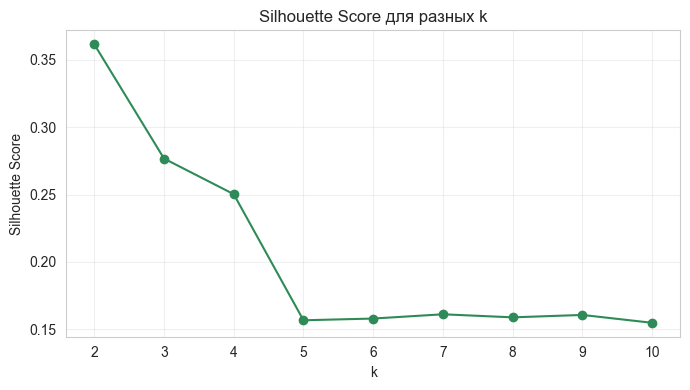

In [158]:
# График silhouette по k (начиная с 2)
plt.figure(figsize=(7, 4))
plt.plot(sil_df["k"], sil_df["silhouette"], "o-", color="seagreen")
plt.xticks(sorted(silhouette_scores.keys()))
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score для разных k")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


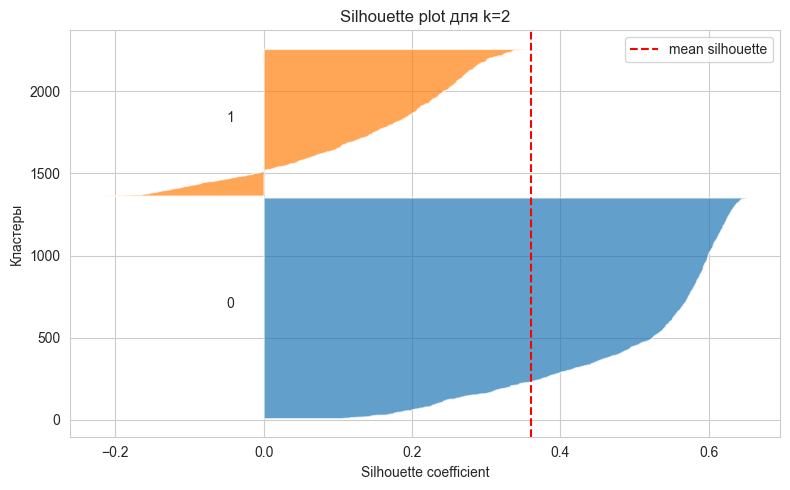

In [159]:
# Silhouette plot (bar) для оптимального k по silhouette
opt_k_sil = best_sil_k
sample_sil = silhouette_samples(X_scaled, labels_by_k[opt_k_sil])
labels_opt = labels_by_k[opt_k_sil]

plt.figure(figsize=(8, 5))
y_lower = 10
for i in range(opt_k_sil):
    ith = sample_sil[labels_opt == i]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(silhouette_scores[opt_k_sil], color="red", linestyle="--", label="mean silhouette")
plt.title(f"Silhouette plot для k={opt_k_sil}")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Кластеры")
plt.legend()
plt.tight_layout()
plt.show()


### Вывод по пункту 5

Лучший silhouette у **k = 2** (≈ **0.36**). При росте k качество разделения падает.  
Значит, с точки зрения плотности/отделимости наиболее убедительны **2 крупных сегмента**.


## 6. Метрики качества и выбор оптимального k

- **Davies-Bouldin** — чем **меньше**, тем лучше (кластеры плотные и далёкие).  
- **Calinski-Harabasz** — чем **больше**, тем лучше (разброс между группами велик относительно внутригруппового).


In [160]:
# Считаем метрики для каждого k
# inertia есть всегда; silhouette/DB/CH — только при k >= 2
rows = []
for k in ks:
    labels = labels_by_k[k]
    row = {
        "k": k,
        "inertia": kmeans_models[k].inertia_,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
    }
    if k >= 2:
        row["silhouette"] = silhouette_score(X_scaled, labels)
        row["davies_bouldin"] = davies_bouldin_score(X_scaled, labels)
        row["calinski_harabasz"] = calinski_harabasz_score(X_scaled, labels)
    rows.append(row)

metrics_df = pd.DataFrame(rows)
display(metrics_df.round(4))


,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,1,29107.0000,NaN,NaN,NaN
1,2,18813.8914,0.3613,1.2667,1223.8661
2,3,16199.9804,0.2766,1.6391,890.7510
3,4,15198.3392,0.2502,1.9399,681.7847
4,5,14382.0075,0.1568,1.9954,571.8192
5,6,13607.5953,0.1581,2.0265,508.6890
6,7,13092.6978,0.1613,1.9918,455.0109
7,8,12683.8093,0.1590,1.9361,412.6761
8,9,12193.0129,0.1608,1.8846,386.6783
9,10,11885.0109,0.1549,1.7948,358.8817


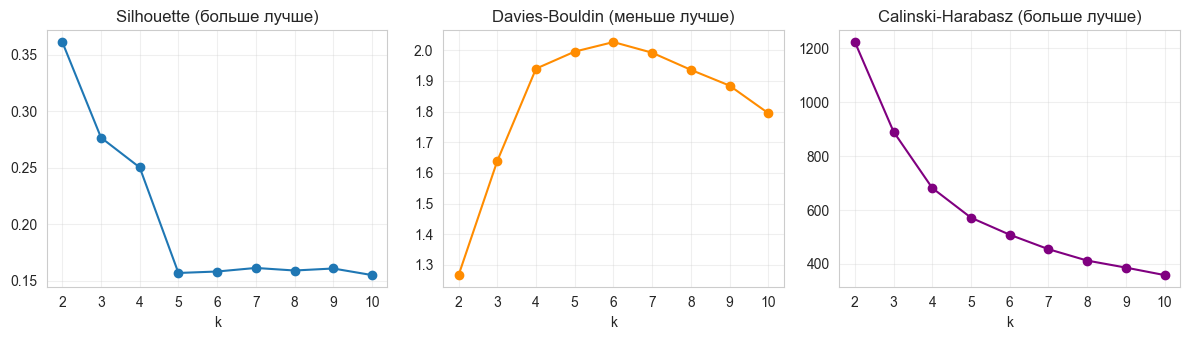

In [161]:
# Визуальное сравнение метрик (k=1 на silhouette/DB/CH будет пустым/NaN)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
m2 = metrics_df[metrics_df["k"] >= 2]
axes[0].plot(m2["k"], m2["silhouette"], "o-")
axes[0].set_title("Silhouette (больше лучше)")
axes[1].plot(m2["k"], m2["davies_bouldin"], "o-", color="darkorange")
axes[1].set_title("Davies-Bouldin (меньше лучше)")
axes[2].plot(m2["k"], m2["calinski_harabasz"], "o-", color="purple")
axes[2].set_title("Calinski-Harabasz (больше лучше)")
for ax in axes:
    ax.set_xlabel("k"); ax.grid(True, alpha=0.3); ax.set_xticks(sorted(m2["k"].tolist()))
plt.tight_layout()
plt.show()


In [162]:
# Выбор k по совокупности: только среди k >= 2, где метрики определены
rank_df = metrics_df[metrics_df["k"] >= 2].copy()
rank_df["r_sil"] = rank_df["silhouette"].rank(ascending=False)
rank_df["r_db"] = rank_df["davies_bouldin"].rank(ascending=True)
rank_df["r_ch"] = rank_df["calinski_harabasz"].rank(ascending=False)
rank_df["rank_sum"] = rank_df["r_sil"] + rank_df["r_db"] + rank_df["r_ch"]

best_k = int(rank_df.sort_values("rank_sum").iloc[0]["k"])
print("Оптимальный k по совокупности метрик:", best_k)
display(rank_df[["k", "silhouette", "davies_bouldin", "calinski_harabasz", "rank_sum"]].round(4))


Оптимальный k по совокупности метрик: 2


,k,silhouette,davies_bouldin,calinski_harabasz,rank_sum
1,2,0.3613,1.2667,1223.8661,3.0
2,3,0.2766,1.6391,890.7510,6.0
3,4,0.2502,1.9399,681.7847,12.0
4,5,0.1568,1.9954,571.8192,20.0
5,6,0.1581,2.0265,508.6890,21.0
6,7,0.1613,1.9918,455.0109,17.0
7,8,0.1590,1.9361,412.6761,18.0
8,9,0.1608,1.8846,386.6783,17.0
9,10,0.1549,1.7948,358.8817,21.0


### Вывод по пункту 6

По совокупности Silhouette / Davies-Bouldin / Calinski-Harabasz оптимально **k = 2**.  
Локоть также показал 2, и метрики показывают значение 2 — его и берём как основной `best_k`.


## 7. DBSCAN

DBSCAN ищет плотные группы клиентов.  
- `eps` — радиус соседства;  
- `min_samples` — сколько соседей нужно, чтобы точка считалась ядром.  
Точки вне плотности помечаются как шум (`-1`). Число кластеров алгоритм выбирает сам.


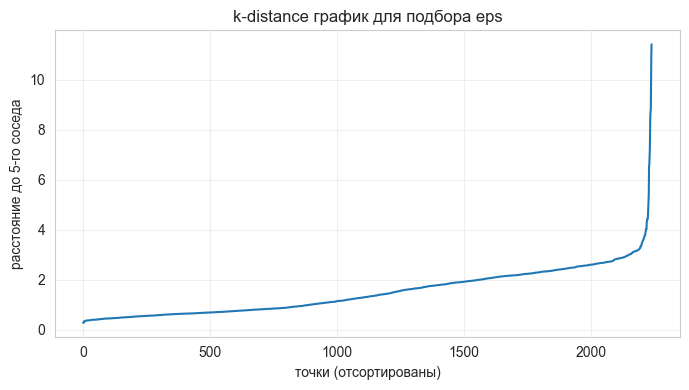

Выбранный eps: 2.619 | min_samples: 5


In [163]:
# Сколько соседей нужно точке, чтобы считаться «ядром» плотной группы
min_samples = 5

# Ищем для каждого клиента его ближайших соседей
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)  # запоминаем расположение всех клиентов
dists, _ = neighbors.kneighbors(X_scaled)  # расстояния до ближайших соседей

# Берём расстояние до самого дальнего из этих 5 соседей и сортируем
k_dist = np.sort(dists[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_dist)
plt.title("k-distance график для подбора eps")
plt.xlabel("точки (отсортированы)")
plt.ylabel(f"расстояние до {min_samples}-го соседа")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Практичный выбор eps: 90-й процентиль этих расстояний 
# (берём такое расстояние, что у 90% клиентов оно меньше или равно ему.)
eps = float(np.percentile(k_dist, 90))
print("Выбранный eps:", round(eps, 3), "| min_samples:", min_samples)


In [164]:
# Пробуем несколько значений eps рядом с выбранным (чуть меньше и чуть больше)
eps_grid = sorted(set([
    round(eps * 0.8, 3),
    round(eps * 0.9, 3),
    round(eps, 3),
    round(eps * 1.1, 3),
    round(eps * 1.2, 3),
]))

db_rows = []  # сюда сложим метрики по каждому eps
db_labels = {}  # сюда сохраним метки кластеров

for e in eps_grid:
    # Запускаем DBSCAN с текущим радиусом соседства
    db = DBSCAN(eps=e, min_samples=min_samples)
    lab = db.fit_predict(X_scaled)  # метка кластера или -1 (шум)
    db_labels[e] = lab

    # Сколько настоящих кластеров (без шума) и сколько шумовых точек
    n_clusters = len(set(lab) - {-1})
    n_noise = int((lab == -1).sum())

    # Метрики считаем только если есть хотя бы 2 кластера и не все точки — шум
    if n_clusters >= 2 and n_noise < len(lab):
        
        mask = lab != -1  # оставляем только не-шум
        # Silhouette: насколько точки хорошо сидят в своих кластерах
        sil = silhouette_score(X_scaled[mask], lab[mask]) if mask.sum() > n_clusters else np.nan
        # Davies-Bouldin: меньше = лучше разделённые кластеры
        db_idx = davies_bouldin_score(X_scaled[mask], lab[mask])
        # Calinski-Harabasz: больше = лучше
        ch = calinski_harabasz_score(X_scaled[mask], lab[mask])
        
    else:
        # Если кластеров слишком мало — метрики не считаем
        sil, db_idx, ch = np.nan, np.nan, np.nan

    # Сохраняем результат для этой настройки eps
    db_rows.append({
        "eps": e,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette": sil,
        "davies_bouldin": db_idx,
        "calinski_harabasz": ch,
    })

# Таблица сравнения всех испытанных eps
db_metrics = pd.DataFrame(db_rows)
display(db_metrics.round(4))


,eps,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
0,2.095,2,456,0.2733,0.7588,7.8747
1,2.357,3,225,0.2762,0.9348,12.0549
2,2.619,1,111,NaN,NaN,NaN
3,2.881,1,55,NaN,NaN,NaN
4,3.143,1,32,NaN,NaN,NaN


Лучший eps: 2.357
Кластеров DBSCAN: 3
Шумовых точек: 225


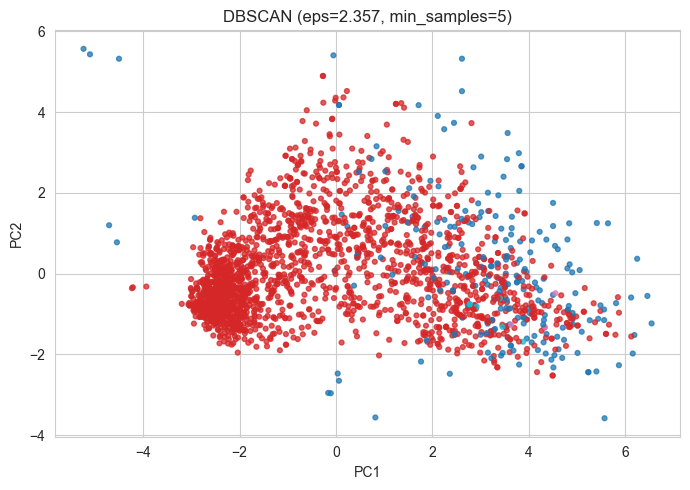

In [165]:
# Оставляем строки, где silhouette удалось посчитать
valid = db_metrics.dropna(subset=["silhouette"])

# Если есть валидные варианты — берём eps с лучшим silhouette
if len(valid):
    best_eps = float(valid.sort_values("silhouette", ascending=False).iloc[0]["eps"])
else:
    # Если метрик нет — оставляем исходный eps
    best_eps = eps

# Метки DBSCAN для лучшего eps
labels_db = db_labels[best_eps]

# Число кластеров без учёта шума (-1)
n_db_clusters = len(set(labels_db) - {-1})
print("Лучший eps:", best_eps)
print("Кластеров DBSCAN:", n_db_clusters)
print("Шумовых точек:", int((labels_db == -1).sum()))

# Рисуем результат на 2D (PCA), цвет = номер кластера
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_db, cmap="tab10", s=12, alpha=0.75)
plt.title(f"DBSCAN (eps={best_eps}, min_samples={min_samples})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


### Как eps и min_samples влияют на результат

1. **Больше `eps`** — проще соединить точки в один кластер → кластеров меньше, шума меньше.  
2. **Меньше `eps`** — кластеры дробятся сильнее, больше точек уходит в шум.  
3. **Больше `min_samples`** — требования к плотности жёстче → больше шума, меньше/плотнее кластеры.  

• DBSCAN нашёл 3 кластера и 225 шумовых точек;


• silhouette ≈ 0.28 (у KMeans ≈ 0.36);


• Calinski-Harabasz очень низкий ≈ 12 (у KMeans ≈ 1224).

На этих клиентах DBSCAN сработал хуже KMeans: группы получились менее чёткие, много точек ушло в шум.

## 8. Иерархическая кластеризация

Смотрим сначала каждый клиента по отдельности, потом сливаем ближайшие группы.  
**Дендрограмма** показывает дерево слияний: на какой высоте обрезать — столько кластеров и получим.


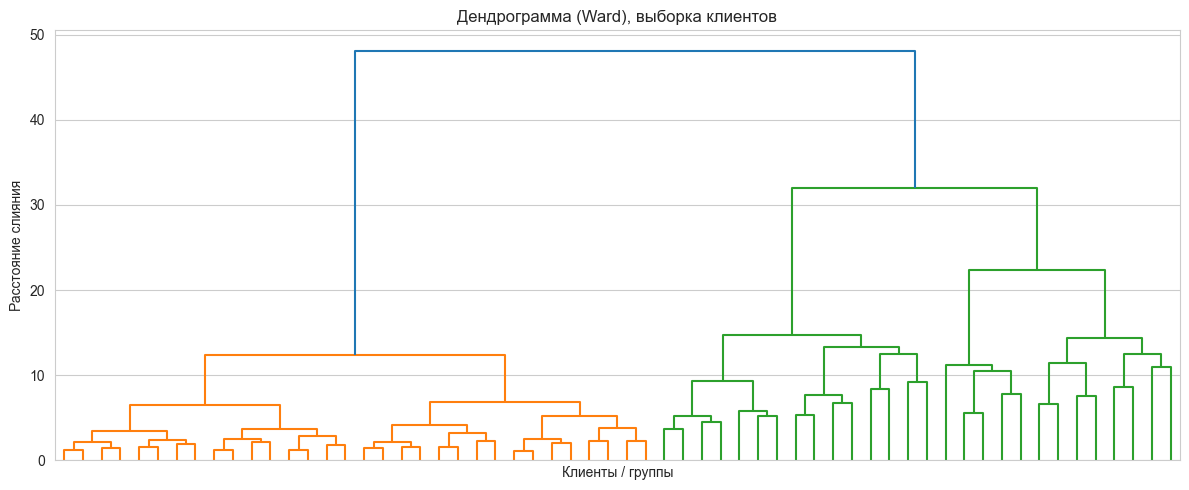

In [166]:
# Для дендрограммы берём выборку — иначе дерево слишком тяжёлое
sample_idx = X_scaled.sample(n=min(300, len(X_scaled)), random_state=RANDOM_STATE).index
X_sample = X_scaled.loc[sample_idx]

# linkage: расстояния между кластерами (ward — минимизация дисперсии)
Z = linkage(X_sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="level", p=5, no_labels=True)
plt.title("Дендрограмма (Ward), выборка клиентов")
plt.xlabel("Клиенты / группы")
plt.ylabel("Расстояние слияния")
plt.tight_layout()
plt.show()


Иерархических кластеров: 2
Silhouette: 0.3404
Davies-Bouldin: 1.3127
Calinski-Harabasz: 1126.2568


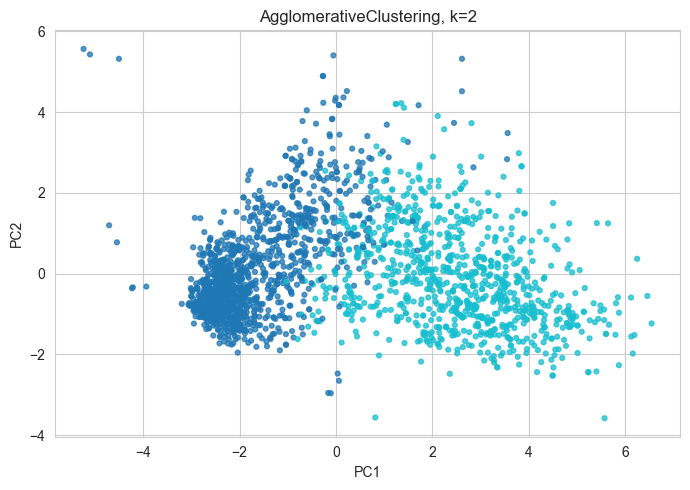

In [167]:
# AgglomerativeClustering с числом кластеров = best_k (из KMeans-метрик)
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_agg = agg.fit_predict(X_scaled)

print("Иерархических кластеров:", best_k)
print("Silhouette:", round(silhouette_score(X_scaled, labels_agg), 4))
print("Davies-Bouldin:", round(davies_bouldin_score(X_scaled, labels_agg), 4))
print("Calinski-Harabasz:", round(calinski_harabasz_score(X_scaled, labels_agg), 4))

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_agg, cmap="tab10", s=12, alpha=0.75)
plt.title(f"AgglomerativeClustering, k={best_k}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


### Вывод по пункту 8

Дендрограмма помогает увидеть естественные уровни объединения клиентов.  
Для сравнения с KMeans берём то же `best_k` = 2 и считаем те же метрики качества.


## 9. Интерпретация кластеров

Метки кластеров сами по себе ничего не значат для бизнеса.  
Нужно посмотреть **средние** доход/траты/покупки в каждой группе и описать сегменты человеческим языком.


In [168]:
# Для интерпретации берём KMeans с best_k
final_labels = labels_by_k[best_k]
data_clusters = data.copy()
data_clusters["cluster"] = final_labels

# Средние значения признаков по кластерам
cluster_profile = data_clusters.groupby("cluster")[feature_cols].mean()
cluster_size = data_clusters["cluster"].value_counts().sort_index().rename("size")

profile = cluster_profile.copy()
profile.insert(0, "size", cluster_size)
display(profile.round(2))


,size,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
cluster,,,,,,,,,,,,,,
0,1345,38974.82,48.78,107.32,6.22,36.36,9.46,6.35,22.46,2.52,2.96,0.91,3.94,6.42
1,894,71504.78,49.63,600.07,56.53,363.58,79.79,58.25,76.50,2.02,5.78,5.31,8.58,3.66


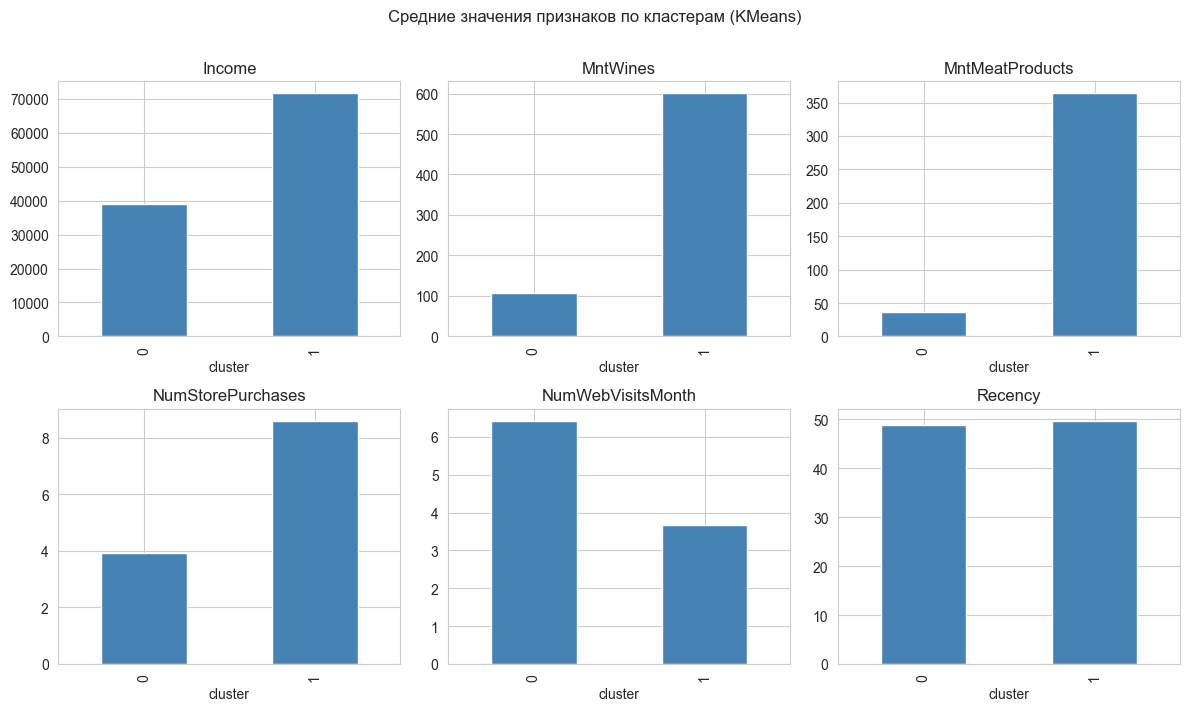

In [169]:
# Bar chart средних по ключевым признакам
key_feats = ["Income", "MntWines", "MntMeatProducts", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]
plot_df = cluster_profile[key_feats]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, key_feats):
    plot_df[col].plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("cluster")
plt.suptitle("Средние значения признаков по кластерам (KMeans)", y=1.01)
plt.tight_layout()
plt.show()


In [170]:
# Короткое авто-описание сегментов по z-оценкам средних
profile_z = (cluster_profile - cluster_profile.mean()) / cluster_profile.std(ddof=0)

def describe_cluster(cid):
    row = profile_z.loc[cid]
    high = row.nlargest(3).index.tolist()
    low = row.nsmallest(3).index.tolist()
    return high, low

print("Интерпретация кластеров (относительно других групп):")
for cid in sorted(data_clusters["cluster"].unique()):
    high, low = describe_cluster(cid)
    size = int(cluster_size.loc[cid])
    print(f"\nКластер {cid} (n={size}):")
    print("  выше среднего:", ", ".join(high))
    print("  ниже среднего:", ", ".join(low))


Интерпретация кластеров (относительно других групп):

Кластер 0 (n=1345):
  выше среднего: NumDealsPurchases, NumWebVisitsMonth, Recency
  ниже среднего: MntSweetProducts, Income, MntWines

Кластер 1 (n=894):
  выше среднего: Recency, MntMeatProducts, NumWebPurchases
  ниже среднего: NumWebVisitsMonth, NumDealsPurchases, NumStorePurchases


### Вывод по пункту 9

По средним профилям KMeans (k=2):

1. **Кластер 0 (~1345 клиентов)** — более низкий доход (~39k), маленькие траты на вино/мясо, больше визитов сайта и покупок со скидками: «экономные / часто смотрят сайт».  
2. **Кластер 1 (~894 клиента)** — высокий доход (~71k), большие траты, больше покупок в магазине/каталоге/сайте, меньше визитов: «премиальные покупатели».  

Сильнее всего различаются **Income** и суммы `Mnt*`.

Можно явно выделить два класса бедных и богатых клиентов.


## 10. Сравнение алгоритмов

Сравниваем KMeans, DBSCAN и иерархию по метрикам и по тому, насколько кластеры визуально отделимы на PCA-плоскости.


In [171]:
# Сводка метрик трёх алгоритмов
def safe_metrics(X, labels, name):
    labels = np.asarray(labels)
    uniq = set(labels)
    if -1 in uniq:
        mask = labels != -1
        X_m, y_m = X[mask], labels[mask]
        n_clusters = len(set(y_m))
        n_noise = int((~mask).sum())
    else:
        X_m, y_m = X, labels
        n_clusters = len(set(y_m))
        n_noise = 0
    if n_clusters < 2:
        return {"algorithm": name, "n_clusters": n_clusters, "n_noise": n_noise,
                "silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    return {
        "algorithm": name,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette": silhouette_score(X_m, y_m),
        "davies_bouldin": davies_bouldin_score(X_m, y_m),
        "calinski_harabasz": calinski_harabasz_score(X_m, y_m),
    }

compare = pd.DataFrame([
    safe_metrics(X_scaled.values, labels_by_k[best_k], f"KMeans (k={best_k})"),
    safe_metrics(X_scaled.values, labels_db, f"DBSCAN (eps={best_eps})"),
    safe_metrics(X_scaled.values, labels_agg, f"Hierarchical (k={best_k})"),
])
display(compare.round(4))


,algorithm,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
0,KMeans (k=2),2,0,0.3613,1.2667,1223.8661
1,DBSCAN (eps=2.357),3,225,0.2762,0.9348,12.0549
2,Hierarchical (k=2),2,0,0.3404,1.3127,1126.2568


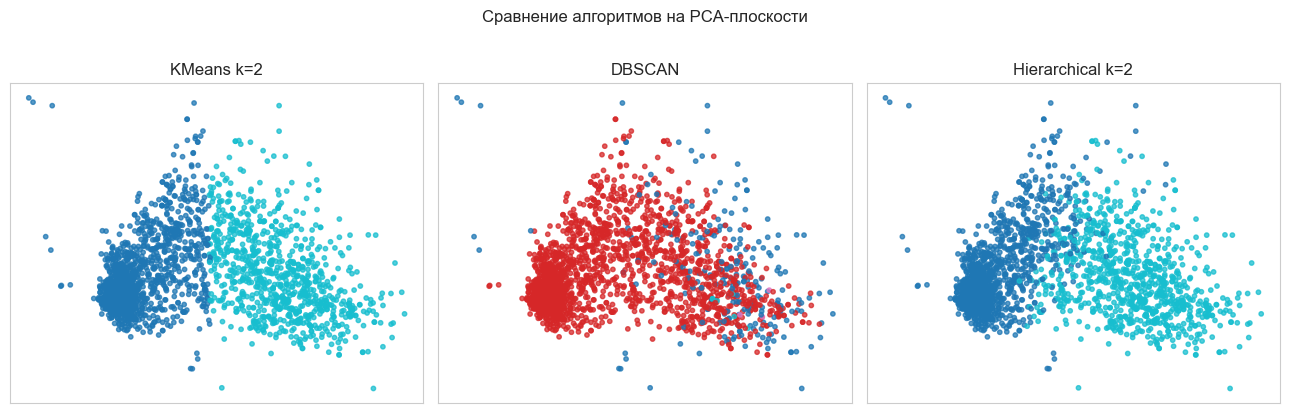

In [172]:
# Визуальное сравнение трёх алгоритмов
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_by_k[best_k], cmap="tab10", s=10, alpha=0.75)
axes[0].set_title(f"KMeans k={best_k}")
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_db, cmap="tab10", s=10, alpha=0.75)
axes[1].set_title("DBSCAN")
axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_agg, cmap="tab10", s=10, alpha=0.75)
axes[2].set_title(f"Hierarchical k={best_k}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Сравнение алгоритмов на PCA-плоскости", y=1.02)
plt.tight_layout()
plt.show()


In [173]:
# Сравнение KMeans с масштабированием и без него по всем метрикам
km_raw = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_raw = km_raw.fit_predict(data[feature_cols])  # без scaler
labels_scaled = labels_by_k[best_k]  # уже обученный KMeans на X_scaled

# Метрики считаем в том же пространстве, где учили модель
X_raw = data[feature_cols]

scale_compare = pd.DataFrame([
    {
        "вариант": "Без масштабирования",
        "k": best_k,
        "inertia": km_raw.inertia_,
        "silhouette": silhouette_score(X_raw, labels_raw),
        "davies_bouldin": davies_bouldin_score(X_raw, labels_raw),
        "calinski_harabasz": calinski_harabasz_score(X_raw, labels_raw),
    },
    {
        "вариант": "С масштабированием",
        "k": best_k,
        "inertia": kmeans_models[best_k].inertia_,
        "silhouette": silhouette_score(X_scaled, labels_scaled),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels_scaled),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels_scaled),
    },
])

display(scale_compare.round(4))


,вариант,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,Без масштабирования,2,3.259750e+11,0.5987,0.5326,4806.1561
1,С масштабированием,2,1.881389e+04,0.3613,1.2667,1223.8661


Без масштабирования метрики выглядят лучше (silhouette ≈ **0.60** против **0.36**), но это **ловушка**: расстояние почти полностью определяет `Income`, остальные признаки почти не участвуют.  
`inertia` между вариантами сравнивать нельзя — разные единицы.  
Для сегментации по поведению клиентов нужен вариант **с масштабированием**: метрики скромнее, зато кластеры честнее по смыслу.


### Вывод по сравнению алгоритмов

| Алгоритм | Silhouette | DB ↓ | CH ↑ | Комментарий |
|--|--|--|--|--|
| KMeans k=2 | **0.36** | 1.27 | **1224** | лучший баланс метрик |
| Hierarchical k=2 | 0.34 | 1.31 | 1126 | близко к KMeans |
| DBSCAN | 0.28 | 0.93 | 12 | 3 кластера + 225 шум |

1. **KMeans** здесь лучший для сегментации: выше silhouette/CH, понятные группы.  
2. **Hierarchical** почти такой же, плюс дендрограмма.  
3. **DBSCAN** находит шум, но кластеры слабее по CH и хуже интерпретируются.  
4. Silhouette **без** масштабирования выше (~0.60), но это ловушка: без scaler всё решает `Income`. Для честного поведения клиентов нужен **StandardScaler**.  
5. Итог сравнения: для этой задачи берём **KMeans + масштабирование**.


## 11. Финальный вывод

1. **Лучший алгоритм:** KMeans (после StandardScaler).  
2. **Оптимальное число кластеров:** **2** (по совокупности метрик; локоть около 3 — запасной вариант).  
3. **Сегменты клиентов:**  
   - экономные клиенты с низкой тратой и высокой «онлайн-активностью»;  
   - премиальные клиенты с высоким доходом и большими покупками.  

**Итог:** для маркетинга достаточно двух ярких сегментов; масштабирование обязательно, иначе сегментация схлопывается к доходу.
